In [1]:
import numpy as np
import torch

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [5]:
min(len(w) for w in words) 

2

In [6]:
max(len(w) for w in words)

15

In [7]:
b = {}

for w in words:
    chs = ['.']+ list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigrams = (ch1, ch2)
        b[bigrams] = b.get(bigrams, 0) + 1

In [8]:
sorted(b.items(), key=lambda kv: -kv[1])

[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('.', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '.'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('.', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '.'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('.', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '.'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('.', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('.', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('.', 'l'), 1572),
 (('.', 'c'), 1542),
 (('.', 'e'), 1531),
 (('j', 'a'), 1473),
 (('r', '.'), 1377),
 (('n', 'e'),

In [9]:
N = torch.zeros([27,27], dtype=torch.int32)

In [10]:
len(set(''.join(words)))

26

In [11]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s,i in stoi.items()}

In [12]:
for w in words:
    chs = ['.']+ list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi.get(ch1)
        ix2 = stoi.get(ch2)
        N[ix1, ix2] += 1

(-0.5, 26.5, 26.5, -0.5)

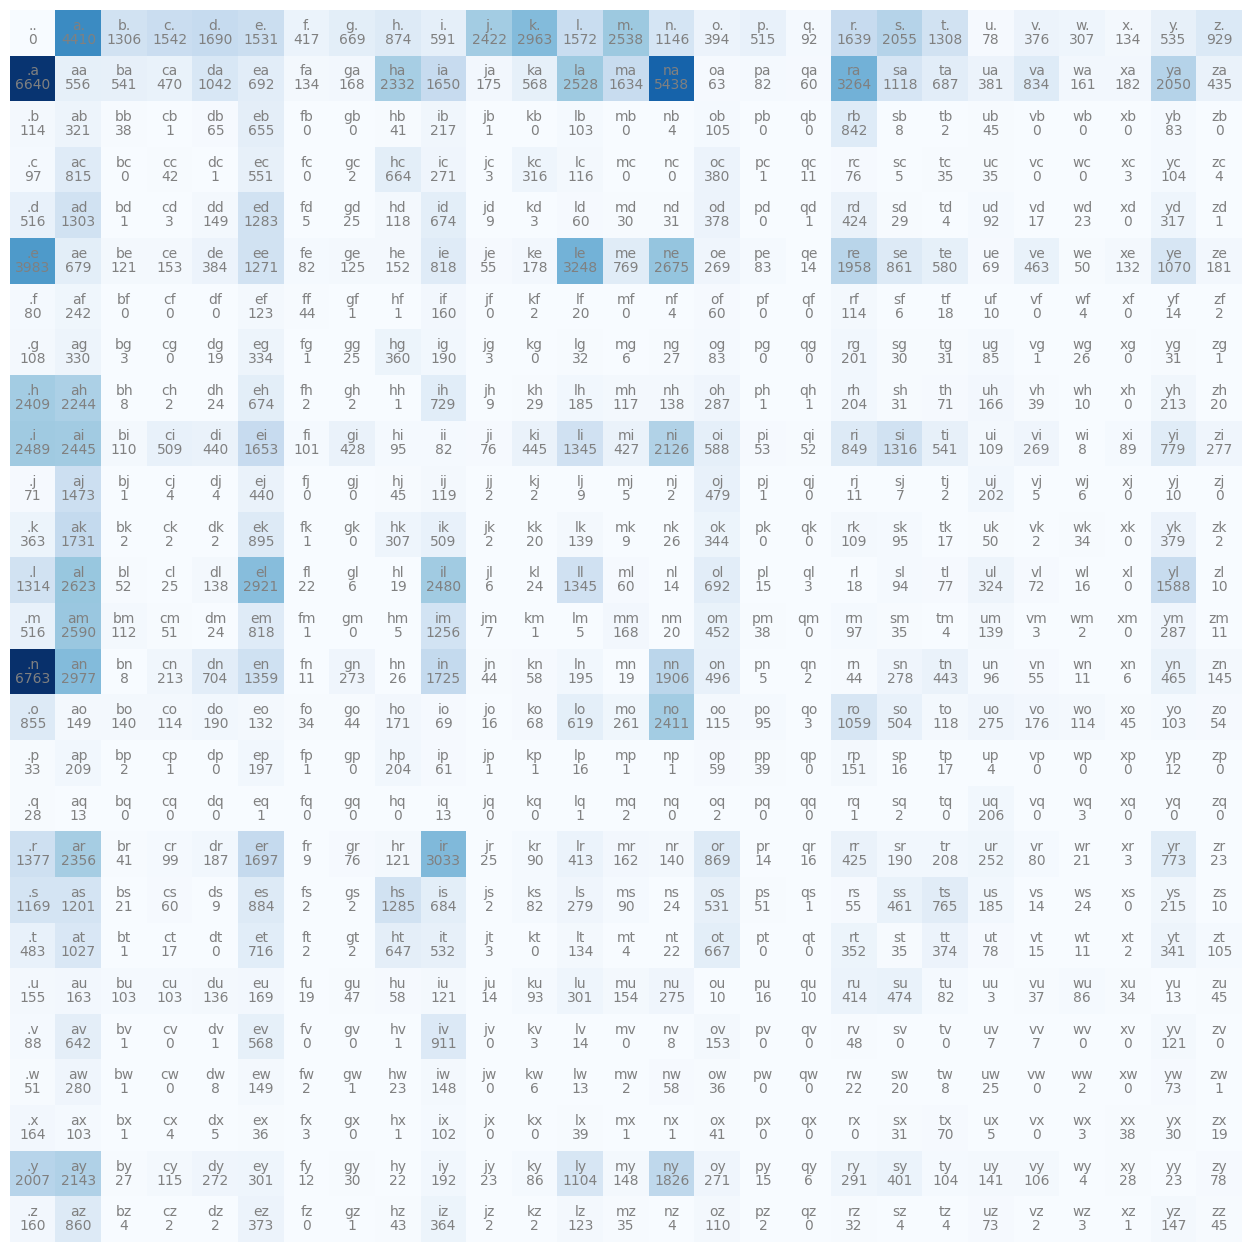

In [13]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(i,j,chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color='gray')
        
plt.axis('off')

In [14]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [15]:
P = N.float()
P /= P.sum(1, keepdims=True)

In [122]:
P

tensor([[0.0000e+00, 1.3767e-01, 4.0770e-02, 4.8138e-02, 5.2758e-02, 4.7794e-02,
         1.3018e-02, 2.0885e-02, 2.7284e-02, 1.8450e-02, 7.5610e-02, 9.2498e-02,
         4.9074e-02, 7.9231e-02, 3.5776e-02, 1.2300e-02, 1.6077e-02, 2.8720e-03,
         5.1166e-02, 6.4153e-02, 4.0833e-02, 2.4350e-03, 1.1738e-02, 9.5839e-03,
         4.1832e-03, 1.6702e-02, 2.9001e-02],
        [1.9596e-01, 1.6408e-02, 1.5966e-02, 1.3870e-02, 3.0751e-02, 2.0422e-02,
         3.9546e-03, 4.9579e-03, 6.8821e-02, 4.8694e-02, 5.1645e-03, 1.6763e-02,
         7.4605e-02, 4.8222e-02, 1.6048e-01, 1.8592e-03, 2.4199e-03, 1.7707e-03,
         9.6326e-02, 3.2994e-02, 2.0274e-02, 1.1244e-02, 2.4613e-02, 4.7514e-03,
         5.3711e-03, 6.0499e-02, 1.2838e-02],
        [4.3100e-02, 1.2136e-01, 1.4367e-02, 3.7807e-04, 2.4575e-02, 2.4764e-01,
         0.0000e+00, 0.0000e+00, 1.5501e-02, 8.2042e-02, 3.7807e-04, 0.0000e+00,
         3.8941e-02, 0.0000e+00, 1.5123e-03, 3.9698e-02, 0.0000e+00, 0.0000e+00,
         3.1834e-

In [17]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(P, num_samples=1, replacement=True, generator=g).item()
ix

ValueError: only one element tensors can be converted to Python scalars

In [18]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
        
    print(''.join(out))

mor.
axx.
minaymoryles.
kondlaisah.
anchshizarie.


In [19]:
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.']+ list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi.get(ch1)
        ix2 = stoi.get(ch2)
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n+=1
        # print(f'{ch1}{ch2}: {prob: .4f} {logprob: .4f}')
        
print(f'log_likelihood:{log_likelihood}')
nll = -log_likelihood
print(f"nll={nll}")
print(f'avg nll:{nll/n}')

log_likelihood:-559891.75
nll=559891.75
avg nll:2.454094171524048


In [20]:
xs, ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1, ix2 = stoi[ch1], stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [21]:
xs

tensor([ 0,  5, 13, 13,  1])

In [22]:
ys

tensor([ 5, 13, 13,  1,  0])

In [28]:
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [29]:
xenc.shape

torch.Size([5, 27])

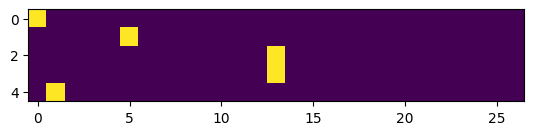

In [30]:
plt.imshow(xenc)

In [31]:
xenc.dtype

torch.float32

In [ ]:
# 5 , 27 @ 27, 27
# 5, 27

w = torch.randn((27,27))
xenc @ w

tensor([[-0.1819, -0.2214, -0.2895, -0.0137, -1.1100,  1.2643,  0.3246, -0.3819,
         -0.0325,  0.4966,  0.6078,  0.3007, -1.6150,  0.5840, -0.3789,  0.3073,
          0.4487, -0.8612,  2.2100, -0.1928, -1.2072, -0.1136,  0.3722, -0.2653,
         -0.0846, -1.7325, -0.4212],
        [ 1.4013, -0.6949, -1.3068,  0.5770,  0.6575,  0.3537, -0.0785, -0.0682,
          0.6949,  0.2169, -0.0864, -0.8804,  0.1221,  1.4127, -0.3985,  1.2789,
          1.3824,  1.1303,  0.6111,  0.2461, -0.4111,  1.1586, -0.7823, -1.5558,
          0.7714, -1.9399,  0.3244],
        [-1.7595, -0.8396, -0.2612, -0.7191, -0.1611, -0.3449,  0.1165, -0.3116,
          0.7681,  0.0165,  0.2229, -0.0244, -1.5211,  0.0948,  1.7504,  0.3972,
          0.0598,  1.0255,  0.1241,  0.1446,  2.8104, -1.6262,  0.6198, -0.4630,
         -0.4832,  0.1826,  0.9084],
        [-1.7595, -0.8396, -0.2612, -0.7191, -0.1611, -0.3449,  0.1165, -0.3116,
          0.7681,  0.0165,  0.2229, -0.0244, -1.5211,  0.0948,  1.7504,  0.3972

In [38]:
logits = (xenc @ w) # log-counts
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0230, 0.0221, 0.0207, 0.0272, 0.0091, 0.0977, 0.0382, 0.0188, 0.0267,
         0.0454, 0.0507, 0.0373, 0.0055, 0.0495, 0.0189, 0.0375, 0.0432, 0.0117,
         0.2516, 0.0228, 0.0083, 0.0246, 0.0400, 0.0212, 0.0254, 0.0049, 0.0181],
        [0.0916, 0.0113, 0.0061, 0.0402, 0.0436, 0.0321, 0.0209, 0.0211, 0.0452,
         0.0280, 0.0207, 0.0094, 0.0255, 0.0927, 0.0152, 0.0811, 0.0899, 0.0699,
         0.0416, 0.0289, 0.0150, 0.0719, 0.0103, 0.0048, 0.0488, 0.0032, 0.0312],
        [0.0035, 0.0088, 0.0157, 0.0099, 0.0174, 0.0145, 0.0229, 0.0150, 0.0440,
         0.0208, 0.0255, 0.0199, 0.0045, 0.0225, 0.1176, 0.0304, 0.0217, 0.0569,
         0.0231, 0.0236, 0.3393, 0.0040, 0.0380, 0.0129, 0.0126, 0.0245, 0.0506],
        [0.0035, 0.0088, 0.0157, 0.0099, 0.0174, 0.0145, 0.0229, 0.0150, 0.0440,
         0.0208, 0.0255, 0.0199, 0.0045, 0.0225, 0.1176, 0.0304, 0.0217, 0.0569,
         0.0231, 0.0236, 0.3393, 0.0040, 0.0380, 0.0129, 0.0126, 0.0245, 0.0506],
        [0.0199, 0.0081,

In [40]:
probs.shape

torch.Size([5, 27])

In [41]:
probs[0]

tensor([0.0230, 0.0221, 0.0207, 0.0272, 0.0091, 0.0977, 0.0382, 0.0188, 0.0267,
        0.0454, 0.0507, 0.0373, 0.0055, 0.0495, 0.0189, 0.0375, 0.0432, 0.0117,
        0.2516, 0.0228, 0.0083, 0.0246, 0.0400, 0.0212, 0.0254, 0.0049, 0.0181])

In [42]:
probs[0].sum()

tensor(1.)

In [43]:
# summary --------------------------->>>>

In [44]:
xs

tensor([ 0,  5, 13, 13,  1])

In [45]:
ys

tensor([ 5, 13, 13,  1,  0])

In [69]:
# randomly initialize 27 neurons weights. each neuron recieves 27 inputs
g = torch.Generator().manual_seed(2147483647)
w = torch.randn((27,27), generator=g, requires_grad=True)

In [102]:
# Forward pass

xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ w

# softmax
counts = logits.exp()
probs = counts/counts.sum(1, keepdim=True)

# negative log likelihood
loss = -probs[torch.arange(5), ys].log().mean()


In [103]:
print(loss.item())

3.6097614765167236


In [104]:
# backward pass
w.grad = None #set to zero the gradient
loss.backward()


In [105]:
w.data += -0.1 * w.grad

In [106]:
########## OPTIMIZATION #########

In [118]:
# create the dataset
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1, ix2 = stoi[ch1], stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the network
g = torch.Generator().manual_seed(2147483647)
w = torch.randn((27,27), generator=g, requires_grad=True)

number of examples:  228146


In [131]:
xenc.shape

torch.Size([1, 27])

In [126]:
# gradient descent
for k in range(100):

    # Forward pass
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ w
    counts = logits.exp()
    probs = counts/counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (w**2).mean()
    print(loss.item())

    # backward pass
    w.grad = None #set to zero the gradient
    loss.backward()
    
    # update
    w.data += -50 * w.grad


2.4834258556365967
2.4833855628967285
2.4833483695983887
2.4833128452301025
2.4832797050476074
2.4832475185394287
2.4832165241241455
2.483186721801758
2.4831578731536865
2.4831297397613525
2.483102798461914
2.483076572418213
2.483050584793091
2.4830257892608643
2.483001232147217
2.4829773902893066
2.4829537868499756
2.48293137550354
2.4829089641571045
2.482887029647827
2.482865571975708
2.4828450679779053
2.4828245639801025
2.482804298400879
2.4827845096588135
2.4827651977539062
2.482745885848999
2.48272705078125
2.482708692550659
2.4826905727386475
2.4826722145080566
2.4826550483703613
2.482637882232666
2.4826207160949707
2.4826037883758545
2.4825868606567383
2.4825708866119385
2.4825549125671387
2.4825387001037598
2.482523202896118
2.4825079441070557
2.482492208480835
2.4824774265289307
2.4824626445770264
2.482447862625122
2.482433557510376
2.48241925239563
2.482405185699463
2.482390880584717
2.482377290725708
2.48236346244812
2.4823501110076904
2.48233699798584
2.4823238849639893
2.

In [129]:
# sample from neural net model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    
    out = []
    ix = 0
    while True:
        
        # Before
        # p = P[ix]
        
        # Now
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ w
        counts = logits.exp()
        p = counts/counts.sum(1, keepdim=True)
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

mor.
axx.
minaymoryles.
kondlaisah.
anchthizarie.
